In [1]:
import pandas as pd
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from trxtools.utils.names import cleanNames

## Load data

Load TPM tables

In [2]:
df00_uniq = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_uniq_TPM.txt', sep='\t', index_col=0)
df00_uniq = df00_uniq[[col for col in df00_uniq.columns if '120mJ' in col]]
df00_uniq = cleanNames(df00_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'AG241010_', 'none_120mJ_'])
df00_uniq = df00_uniq[['none_1', 'none_2', 'Cyclon_1', 'Cyclon_2']]

df01_multi = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_multimappers_TPM.txt', sep='\t', index_col=0)
df01_multi = df01_multi[[col for col in df01_multi.columns if '120mJ' in col]]
df01_multi = cleanNames(df01_multi, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'AG241010_', 'none_120mJ_'])
df01_multi = df01_multi[['none_1', 'none_2', 'Cyclon_1', 'Cyclon_2']]

## Basic QC

### Number of mapped reads

In [3]:
summary_uniq = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_uniq.list.summary', sep='\t')
summary_uniq = summary_uniq[['Status']+[col for col in summary_uniq.columns if '120mJ' in col]]
summary_uniq = cleanNames(summary_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'AG241010_', 'none_120mJ_'])
summary_uniq = summary_uniq[['Status', 'none_1', 'none_2', 'Cyclon_1', 'Cyclon_2']]

summary_multi = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_multimappers.list.summary', sep='\t')
summary_multi = summary_multi[['Status']+[col for col in summary_multi.columns if '120mJ' in col]]
summary_multi = cleanNames(summary_multi, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'AG241010_', 'none_120mJ_'])
summary_multi = summary_multi[['Status', 'none_1', 'none_2', 'Cyclon_1', 'Cyclon_2']]

/tmp/ipykernel_11515/900826245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_uniq.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


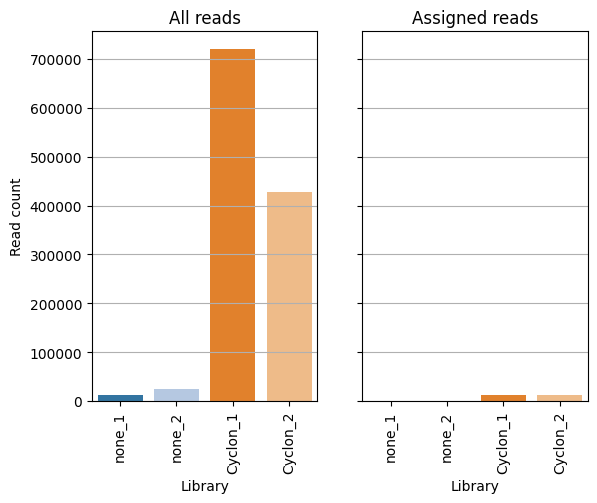

In [4]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_uniq.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_uniq.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)
plt.savefig("../analysis/00_qc_readcounts_unique.png", bbox_inches='tight', dpi=300)

/tmp/ipykernel_11515/1642232271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_multi.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


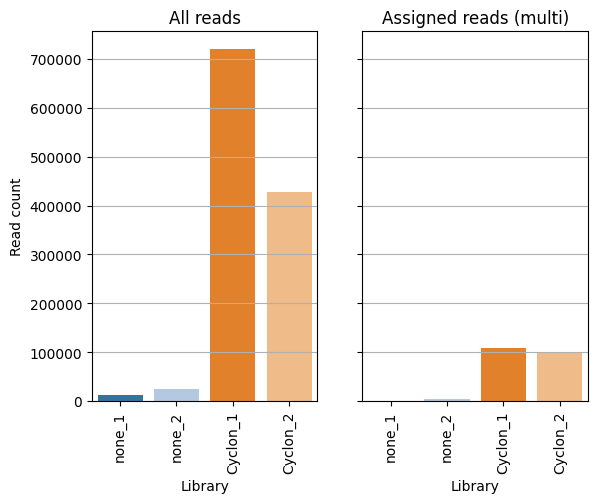

In [5]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_multi.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_multi.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (multi)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)
plt.savefig("../analysis/00_qc_readcounts_multi.png", bbox_inches='tight', dpi=300)

### Sample correlations

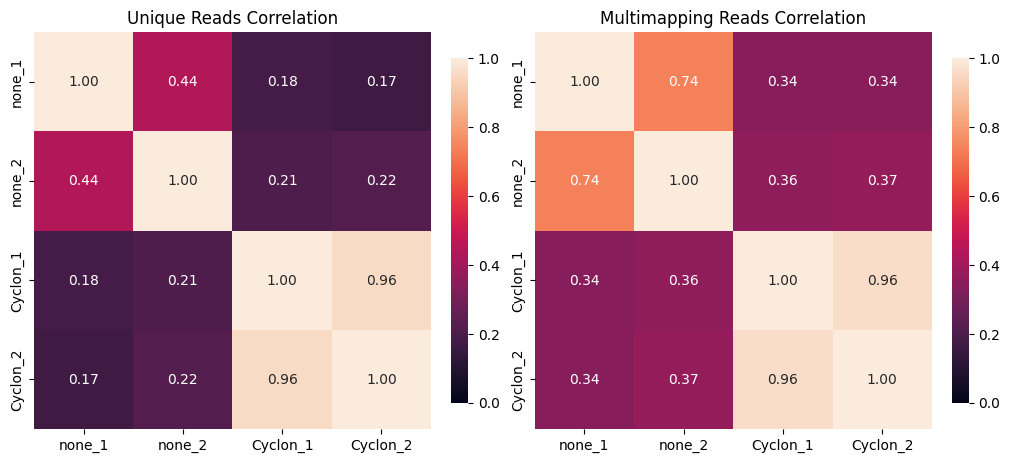

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(df00_uniq.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[0])
axes[0].set_title("Unique Reads Correlation")

sns.heatmap(df01_multi.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[1])
axes[1].set_title("Multimapping Reads Correlation")
plt.savefig("../analysis/00_qc_correlation_heatmaps.png", dpi=300)

## Read classes
Look at what kinds of loci reads map to

Get gene types from GTF file

In [7]:
gtf_classes = pd.read_csv("../references/gtf_classes.csv", index_col='gene_id')

Add gene_class info to df's, also fix tRNA class by looking at gene_name

In [8]:
for df_name in [
    "df00_uniq", "df01_multi"
]:
    df = globals()[df_name].drop(columns=gtf_classes.columns, errors='ignore')
    df = pd.concat([df, gtf_classes], axis=1)
    df.loc[df.index.str.contains('tRNA'), 'gene_type'] = 'tRNA'
    mask = df.filter(regex=r'^gene_type$').eq('tRNA').any(axis=1).to_numpy()
    gene_name_positions = [col_idx for col_idx, col in enumerate(df.columns) if col == 'gene_name']
    for pos in gene_name_positions:
        df.iloc[mask, pos] = df.index[mask]
    globals()[df_name] = df

In [9]:
df00_uniq.to_csv("../analysis/00_Cyclon_allsamples_featureCounts_TPM_geneclasses_unique.csv")
df01_multi.to_csv("../analysis/00_Cyclon_allsamples_featureCounts_TPM_geneclasses_multimapping.csv")

Prepare df for plotting

In [10]:
# Calculate percentages for barplot
bar_uniq = df00_uniq.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1) # type: ignore
bar_multi = df01_multi.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

#filter out some classes and sum them into 'other'
keep = [
    'Mt_rRNA', 'Mt_tRNA', 'lncRNA', 'miRNA',
    'polymorphic_pseudogene',
    'protein_coding', 'rRNA', 'rRNA_pseudogene',
    'snRNA', 'snoRNA', 'tRNA'
]

bar_uniq_keep = bar_uniq.loc[:,bar_uniq.columns.isin(keep)]
bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
bar_uniq_keep = bar_uniq_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_plot = pd.concat([bar_uniq_keep, pd.DataFrame(bar_uniq.loc[:,~bar_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_plot = bar_uniq_plot.rename({0: 'other'}, axis=1)

bar_multi_keep = bar_multi.loc[:,bar_multi.columns.isin(keep)]
bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
bar_multi_keep = bar_multi_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_plot = pd.concat([bar_multi_keep, pd.DataFrame(bar_multi.loc[:,~bar_multi.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_plot = bar_multi_plot.rename({0: 'other'}, axis=1)

/tmp/ipykernel_11515/832184679.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
/tmp/ipykernel_11515/832184679.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']


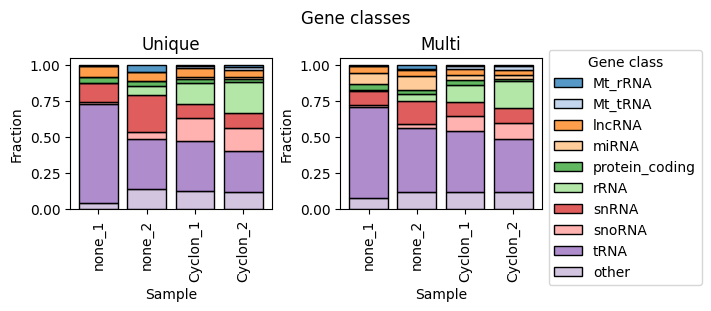

In [11]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Unique")
axes[1].set_title("Multi")
plt.suptitle("Gene classes")
plt.savefig('../analysis/00_read_classes_unique_comparison.png', dpi=300, bbox_inches='tight')

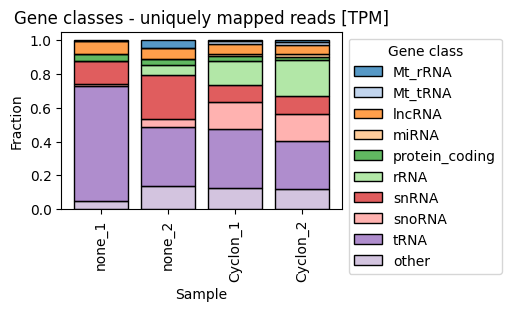

In [12]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('../analysis/00_read_classes_unique_TPMonly.png', dpi=300, bbox_inches='tight')

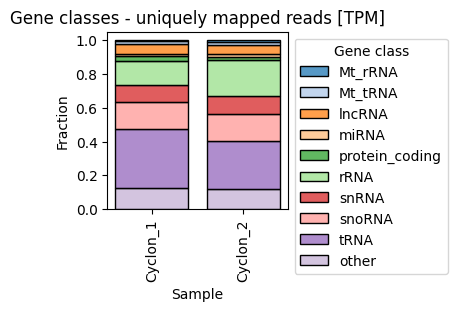

In [13]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_uniq_plot.T[['Cyclon_1', 'Cyclon_2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('../analysis/00_read_classes_unique_TPMonly_simple.png', dpi=300, bbox_inches='tight')

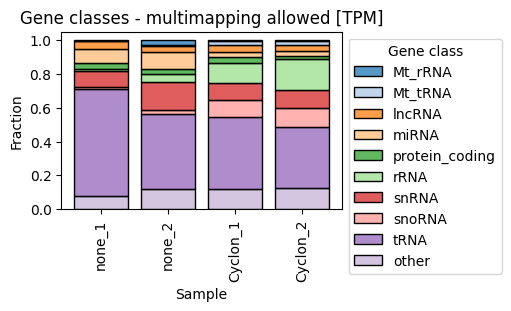

In [14]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
plt.savefig('../analysis/00_read_classes_multi_TPMonly.png', dpi=300, bbox_inches='tight')

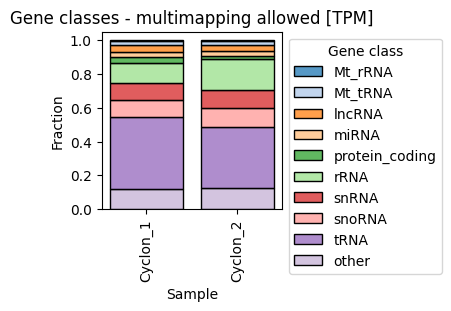

In [15]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_multi_plot.T[['Cyclon_1', 'Cyclon_2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
plt.savefig('../analysis/00_read_classes_multi_TPMonly_simple.png', dpi=300, bbox_inches='tight')

### Top hits table

In [16]:
df_hits = df00_uniq.copy().assign(Cyclon_mean=lambda x: x[['Cyclon_1', 'Cyclon_2']].mean(axis=1))
df_hits = df_hits.sort_values('Cyclon_mean', ascending=False)
df_hits.to_csv("../analysis/00_uniq_hits_sorted_by_Cyclon_mean.csv", index=False)
df_hits.head(20)

,none_1,none_2,Cyclon_1,Cyclon_2,gene_type,gene_name,Cyclon_mean
ENSG00000277027.1,0.000000,12132.818555,22486.976728,21095.811556,ribozyme,RMRP,21791.394142
ENSG00000269900.3,0.000000,11951.731711,22151.350210,20780.948697,lncRNA,RMRP,21466.149453
ENSG00000202111.1,0.000000,0.000000,20687.722488,21665.085745,misc_RNA,VTRNA1-2,21176.404117
ENSG00000200087.1,0.000000,7850.647300,18278.109232,16976.757891,snoRNA,SNORA73B,17627.433561
tRNA30031,0.000000,0.000000,15294.234140,18013.889760,tRNA,tRNA30031,16654.061950
tRNA35832,0.000000,0.000000,14121.853823,13697.792787,tRNA,tRNA35832,13909.823305
ENSG00000201321.1,0.000000,0.000000,10314.886843,16360.613010,rRNA,RNA5S9,13337.749926
tRNA20137,0.000000,0.000000,13556.979670,13012.903148,tRNA,tRNA20137,13284.941409
ENSG00000199568.1,0.000000,13806.310770,13177.150498,11619.506985,snRNA,RNU5A-1,12398.328742
ENSG00000286171.1,0.000000,0.000000,10689.157047,11520.194959,lncRNA,ENSG00000286171,11104.676003


### Percent values of classes

In [17]:
bar_uniq_plot

,Mt_rRNA,Mt_tRNA,lncRNA,miRNA,protein_coding,rRNA,snRNA,snoRNA,tRNA,other
none_1,0.004621,0.000000,0.077173,0.000000,0.040121,0.000000,0.137027,0.010307,0.685097,0.045652
none_2,0.047718,0.000000,0.065237,0.000000,0.034499,0.059867,0.256970,0.051712,0.347080,0.136918
Cyclon_1,0.007178,0.014919,0.057811,0.016622,0.029581,0.141633,0.099130,0.158232,0.351729,0.123165
Cyclon_2,0.011347,0.020275,0.051001,0.015649,0.020370,0.214783,0.104480,0.157698,0.286860,0.117535


### Top hits in selected classes

#### snRNA

In [18]:
df_top_snrna = df00_uniq[df00_uniq['gene_type'] == 'snRNA'].copy()
df_top_snrna['Cyclon_mean'] = df_top_snrna[['Cyclon_1', 'Cyclon_2']].mean(axis=1)
df_top_snrna = df_top_snrna.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_snrna.head(15)

,none_1,none_2,Cyclon_1,Cyclon_2,gene_type,gene_name,Cyclon_mean
ENSG00000199568.1,0.000000,13806.310770,13177.150498,11619.506985,snRNA,RNU5A-1,12398.328742
ENSG00000202538.1,0.000000,22716.766656,8869.726061,10090.383528,snRNA,RNU4-2,9480.054794
ENSG00000200156.1,62050.016380,27612.621539,8984.420794,9682.922487,snRNA,RNU5B-1,9333.671641
ENSG00000283293.1,0.000000,31737.677806,6354.834220,6335.229164,snRNA,RN7SK,6345.031692
ENSG00000221676.1,0.000000,0.000000,5330.439427,3714.348573,snRNA,RNU6ATAC,4522.394000
ENSG00000274978.1,26857.469777,17927.597566,4234.448407,4680.079202,snRNA,RNU11,4457.263805
ENSG00000276027.1,47985.346001,58722.841807,3705.574443,4929.683426,snRNA,RNU12,4317.628935
ENSG00000238923.1,0.000000,0.000000,3676.165122,4902.940117,snRNA,RNU7-1,4289.552619
ENSG00000264229.1,0.000000,12610.488577,4194.301781,3095.485457,snRNA,RNU4ATAC,3644.893619
ENSG00000200795.1,0.000000,0.000000,3285.083726,3983.046130,snRNA,RNU4-1,3634.064928


#### snoRNA

In [19]:
df_top_snorna = df00_uniq[df00_uniq['gene_type'] == 'snoRNA'].copy()
df_top_snorna['Cyclon_mean'] = df_top_snorna[['Cyclon_1', 'Cyclon_2']].mean(axis=1)
df_top_snorna = df_top_snorna.sort_values('Cyclon_mean', ascending=False)
# df_top_snorna.columns = df_top_snorna.columns[-1:].tolist() + df_top_snorna.columns[:-1].tolist()
df_top_snorna.head(5)

,none_1,none_2,Cyclon_1,Cyclon_2,gene_type,gene_name,Cyclon_mean
ENSG00000200087.1,0.0,7850.647300,18278.109232,16976.757891,snoRNA,SNORA73B,17627.433561
ENSG00000274266.1,0.0,3887.213712,9949.737203,8178.779188,snoRNA,SNORA73A,9064.258196
ENSG00000212607.1,0.0,0.000000,4243.024171,3858.385907,snoRNA,SNORA3B,4050.705039
ENSG00000252213.1,0.0,0.000000,4106.354658,3850.277925,snoRNA,SNORA74D,3978.316291
ENSG00000200959.1,0.0,0.000000,2690.284476,4160.070402,snoRNA,SNORA74A,3425.177439


#### rRNA

In [20]:
tsdf = pd.concat([df00_uniq[df00_uniq['gene_type'] == 'rRNA_pseudogene'],
           df00_uniq[df00_uniq['gene_type'] == 'rRNA']])
tsdf['Cyclon_mean'] = tsdf[['Cyclon_1', 'Cyclon_2']].mean(axis=1)
tsdf = tsdf.sort_values('Cyclon_mean', ascending=False)
# tsdf = tsdf.drop(columns=['gene_type']).apply(lambda x: x/sum(x), axis=1)
tsdf

,none_1,none_2,Cyclon_1,Cyclon_2,gene_type,gene_name,Cyclon_mean
ENSG00000201321.1,0.0,0.0,10314.886843,16360.613010,rRNA,RNA5S9,13337.749926
ENSG00000201185.1,0.0,0.0,7979.440765,10854.637478,rRNA_pseudogene,RNA5SP202,9417.039121
ENSG00000199994.1,0.0,0.0,5651.001026,7038.839120,rRNA_pseudogene,RNA5SP145,6344.920073
ENSG00000252211.1,0.0,0.0,3890.853165,6739.314051,rRNA_pseudogene,RNA5SP473,5315.083608
ENSG00000201920.1,0.0,0.0,4978.283422,5598.599420,rRNA_pseudogene,RNA5SP442,5288.441421
...,...,...,...,...,...,...,...
ENSG00000252546.1,0.0,0.0,0.000000,0.000000,rRNA_pseudogene,RNA5SP466,0.000000
ENSG00000212497.1,0.0,0.0,0.000000,0.000000,rRNA_pseudogene,RNA5SP465,0.000000
ENSG00000252060.1,0.0,0.0,0.000000,0.000000,rRNA_pseudogene,RNA5SP464,0.000000
ENSG00000252539.1,0.0,0.0,0.000000,0.000000,rRNA_pseudogene,RNA5SP462,0.000000
